In [267]:
import numpy as np
import json
from quadrotor_model import nonlin_quad_dyn
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt

In [268]:
with open('config/plant_params.json') as f:
    params = json.load(f)

g = params["g"]
m = params["m"]
kf = params["kf"]
km = params["km"]
l = params["l"]
tau_m = params["tau_m"]
W_eq = params["W_eq"]

data = np.load("models/hover_linearization.npz")
C = data["C"]
x_hover = data["x_hover"]
u_hover = data["u_hover"]

In [269]:
def multisine(t, freqs, amps, phases=None):
    freqs = np.asarray(freqs)
    amps = np.asarray(amps)
    if phases is None:
        phases = 2*np.pi*np.random.rand(len(freqs))
    y = np.zeros_like(t, dtype=float)
    for f, a, ph in zip(freqs, amps, phases):
        y += a * np.sin(2*np.pi*f*t + ph)
    return y

def linear_chirp(t, f0, f1, A=1.0, phase=0.0):
    T = t[-1] - t[0]
    k = (f1 - f0) / T
    tau = t - t[0]
    return A * np.sin(2*np.pi*(f0*tau + 0.5*k*tau**2) + phase)

In [270]:
dt = 0.01
T = 100
ts = np.arange(0,T,dt)
N = len(ts)
M = np.array([
[ 1,-1,-1, 1],
[ 1,-1, 1,-1],
[ 1, 1, 1, 1],
[ 1, 1,-1,-1]
]) * 1/4

In [271]:
# ============== Noiseless dataset ==============================

dv_train = np.zeros((N, 4))
dv_train[:,0] = multisine(ts, np.linspace(0.01, 5, 10), 20*np.ones(10))
dv_train[:,1] = multisine(ts, np.linspace(0.08, 5.1, 10), 10*np.ones(10))
dv_train[:,2] = multisine(ts, np.linspace(0.005, 4.9, 10), 10*np.ones(10))
dv_train[:,3] = multisine(ts, np.linspace(0.03, 5.03, 10), 6*np.ones(10))
dW_nn = dv_train @ M.T
u_nn = (W_eq + dW_nn).T

def u_of_t(u, t_query):
    # interpolates discrete u-samples
    return np.array([
        np.interp(t_query, ts, u[0,:]),
        np.interp(t_query, ts, u[1,:]),
        np.interp(t_query, ts, u[2,:]),
        np.interp(t_query, ts, u[3,:]),
    ])

def rhs(t, x, u):
    return nonlin_quad_dyn(t, x, u_of_t(u, t), params)

sol_nn = solve_ivp(rhs, [ts[0], ts[-1]], x_hover, t_eval=ts, args=(u_nn,))
x_nn = sol_nn.y

y_nn = C @ x_nn

In [272]:
np.savez(
    "data/noiselessdataset.npz",
    ts=ts,
    u_nn=u_nn,
    x_nn=x_nn,
    y_nn=y_nn
)

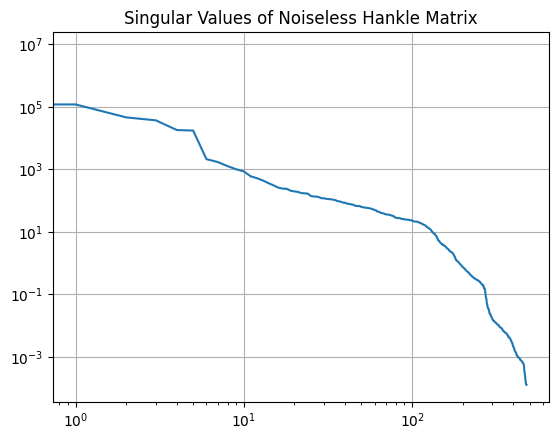

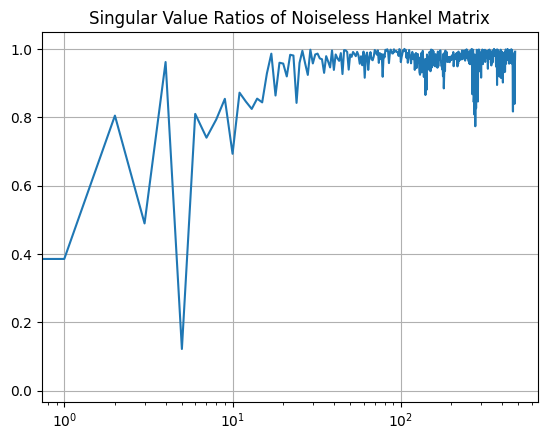

In [273]:
# Build the block Hankel matrix and check the singular value drop
def build_past(M, s):
    d, N = M.shape
    L = N - 2*s + 1
    P = np.zeros((s*d, L))
    for j in range(L):
        P[:,j] = M[:, j:j+s].flatten(order='F')
    return P

def build_future(M, s):
    d, N = M.shape
    L = N - 2*s + 1
    F = np.zeros((s*d, L))
    for j in range(L):
        F[:,j] = M[:,j+s:j+2*s].flatten(order='F')
    return F

Up_train = build_past(u_nn, 40)
Yp_train = build_past(y_nn, 40)
Uf_train = build_future(u_nn, 40)
Yf_train = build_future(y_nn, 40)

# Project orthogonally to row space of Uf to get rid of U effect

Pi_nn = Uf_train.T @ np.linalg.inv(Uf_train @ Uf_train.T) @ Uf_train # projector onto row space of U
Pic_nn = np.eye(Pi_nn.shape[0]) - Pi_nn # complement projector

Yproj_nn = Yf_train @ Pic_nn
U_nn, S_train, Vt_nn = np.linalg.svd(Yproj_nn)

plt.loglog(S_train)
plt.title("Singular Values of Noiseless Hankle Matrix")
plt.grid(True)
plt.savefig("figures/noiseless_hankel.png")
plt.show()

sigma_quotS_trainn = [S_train[i+1] / S_train[i] for i in range(len(S_train)-1)]

plt.semilogx(sigma_quotS_trainn)
plt.title("Singular Value Ratios of Noiseless Hankel Matrix")
plt.grid(True)
plt.savefig("figures/noiseless_hankel_ratios.png")
plt.show()




In [274]:
# ====================== Noisy training dataset- Gaussian noise ==========================
rng = np.random.default_rng(0)

dv_train = np.zeros((N, 4))
dv_train[:,0] = multisine(ts, np.linspace(0.01, 5, 10), 20*np.ones(10))
dv_train[:,1] = multisine(ts, np.linspace(0.08, 5.1, 10), 10*np.ones(10))
dv_train[:,2] = multisine(ts, np.linspace(0.005, 4.9, 10), 10*np.ones(10))
dv_train[:,3] = multisine(ts, np.linspace(0.03, 5.03, 10), 6*np.ones(10))

dW_train = dv_train @ M.T
u_train = (W_eq + dW_train).T

sol_train = solve_ivp(rhs, [ts[0], ts[-1]], x_hover, t_eval=ts, args=(u_train,))
x_train = sol_train.y

# one noise level per state channel
x_noise_frac = np.array([
    0.01, 0.01, 0.01,   # position
    0.02, 0.02, 0.02,   # velocity
    0.005, 0.005, 0.005,# angles
    0.02, 0.02, 0.02,   # angular rates
    0.01, 0.01, 0.01, 0.01  # motor lag states
]).reshape(-1, 1)

sigma_x_train = x_noise_frac * np.std(x_train, axis=1, keepdims=True)
x_train = x_train + sigma_x_train * rng.standard_normal(x_train.shape)

y_train = C @ x_train

# one noise level per output channel
y_noise_frac = np.array([
    0.04, 0.04, 0.04,   # measured position
    0.03, 0.03, 0.03,   # measured velocity
    0.01, 0.01, 0.01,   # measured angles
    0.03, 0.03, 0.03    # measured angular rates
]).reshape(-1, 1)

sigma_y_train = y_noise_frac * np.std(y_train, axis=1, keepdims=True)
y_train = y_train + sigma_y_train * rng.standard_normal(y_train.shape)



In [275]:

np.savez("data/covariances.npz",
         Q=np.diag(x_noise_frac.flatten()),
         R=np.diag(y_noise_frac.flatten())
)

np.savez(
    "data/noisy_train_dataset.npz",
    ts=ts,
    u_train=u_train,
    x_train=x_train,
    y_train=y_train
)

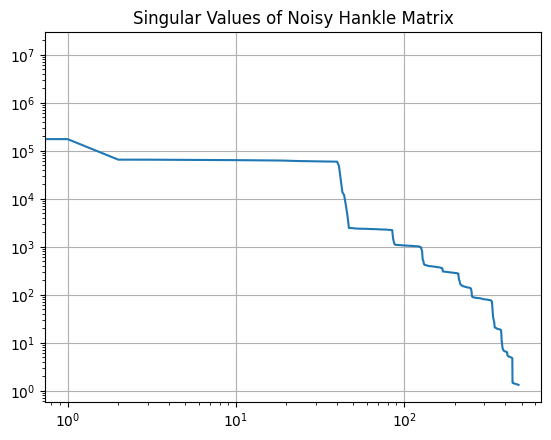

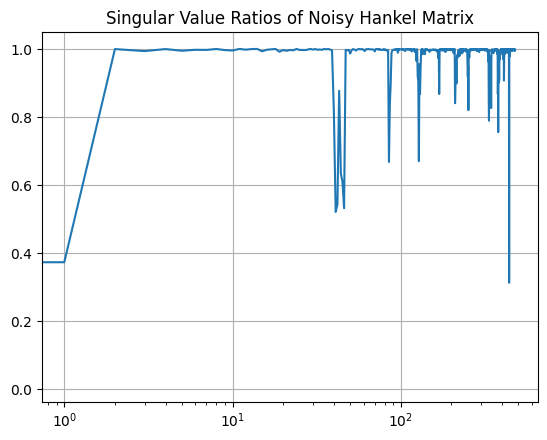

In [276]:
Up_train = build_past(u_train, 40)
Yp_train = build_past(y_train, 40)
Uf_train = build_future(u_train, 40)
Yf_train = build_future(y_train, 40)

# Project orthogonally to row space of Uf to get rid of U effect

Pi_train = Uf_train.T @ np.linalg.inv(Uf_train @ Uf_train.T) @ Uf_train # projector onto row space of U
Pic_train = np.eye(Pi_train.shape[0]) - Pi_train # complement projector

Yproj_train = Yf_train @ Pic_train
U_train, S_train, Vt_train = np.linalg.svd(Yproj_train)

plt.loglog(S_train)
plt.title("Singular Values of Noisy Hankle Matrix")
plt.grid(True)
plt.savefig("figures/noisy_hankel.png")
plt.show()

sigma_quot_train = [S_train[i+1] / S_train[i] for i in range(len(S_train)-1)]

plt.semilogx(sigma_quot_train)
plt.title("Singular Value Ratios of Noisy Hankel Matrix")
plt.grid(True)
plt.savefig("figures/noisy_hankel_ratios.png")
plt.show()


## Interpretation ##

In the noiseless case the singular values are smoothly decreasing, because the state directions are unequally excited, but in the noisy case, a noise floor is brought out around the level of the number of states. So we can see that the order of the model could be around 3 (three most excitable states) or possibly around 16, as expected.


In [277]:
# ====================== Noisy testing dataset- Gaussian noise ==========================
dv_test = np.zeros((N, 4))

rng = np.random.default_rng(42)

freqs0 = rng.uniform(0.02, 4.8, 12)
amps0  = rng.uniform(12, 22, 12)
ph0    = rng.uniform(0, 2*np.pi, 12)
dv_test[:,0] = multisine(ts, freqs0, amps0, ph0)

freqs1 = rng.uniform(0.05, 5.0, 11)
amps1  = rng.uniform(6, 12, 11)
ph1    = rng.uniform(0, 2*np.pi, 11)
dv_test[:,1] = multisine(ts, freqs1, amps1, ph1)

freqs2 = rng.uniform(0.01, 4.7, 13)
amps2  = rng.uniform(7, 13, 13)
ph2    = rng.uniform(0, 2*np.pi, 13)
dv_test[:,2] = multisine(ts, freqs2, amps2, ph2)

freqs3 = rng.uniform(0.03, 5.1, 10)
amps3  = rng.uniform(4, 8, 10)
ph3    = rng.uniform(0, 2*np.pi, 10)
dv_test[:,3] = multisine(ts, freqs3, amps3, ph3)

dW_test = dv_test @ M.T
u_test = (W_eq + dW_test).T

sol_test = solve_ivp(rhs, [ts[0], ts[-1]], x_hover, t_eval=ts, args=(u_test,))
x_test = sol_test.y

# per-state noise levels (length 16)
x_noise_frac_test = np.array([
    0.01, 0.01, 0.01,      # position
    0.02, 0.02, 0.02,      # velocity
    0.05, 0.005, 0.005,   # angles
    0.02, 0.02, 0.02,      # angular rates
    0.01, 0.01, 0.01, 0.01 # motor lag states
]).reshape(-1, 1)

sigma_x_test = x_noise_frac_test * np.std(x_test, axis=1, keepdims=True)
x_test = x_test + sigma_x_test * rng.standard_normal(x_test.shape)

y_test = C @ x_test

# per-output noise levels (length 12 since C picks first 12 states)
y_noise_frac_test = np.array([
    0.02, 0.02, 0.02,    # position outputs
    0.03, 0.03, 0.03,    # velocity outputs
    0.01, 0.01, 0.01,    # angle outputs
    0.03, 0.03, 0.03     # angular rate outputs
]).reshape(-1, 1)

sigma_y_test = y_noise_frac_test * np.std(y_test, axis=1, keepdims=True)
y_test = y_test + sigma_y_test * rng.standard_normal(y_test.shape)

In [278]:
np.savez(
    "data/noisy_test_dataset.npz",
    ts=ts,
    u_test=u_test,
    x_test=x_test,
    y_test=y_test
)

In [279]:
def inv_sqrt_psd(M, tol=1e-10):
    evals, evecs = np.linalg.eigh(M)
    evals = np.maximum(evals, 0.0)
    keep = evals > tol
    if not np.any(keep):
        raise ValueError("Matrix is numerically rank deficient.")
    return (evecs[:, keep] / np.sqrt(evals[keep])) @ evecs[:, keep].T


def project_orthogonal_to_rowspace(A, B):
    # Q spans col(B.T) = row(B)^T
    Q, _ = np.linalg.qr(B.T, mode='reduced')
    return A - (A @ Q) @ Q.T


def subspace_id_cva(u, y, s, n, reg=1e-8):
    nu, N = u.shape
    ny, Ny = y.shape

    L = N - 2*s + 1

    Up = build_past(u, s) 
    Yp = build_past(y, s)  
    Uf = build_future(u, s) 
    Yf = build_future(y, s) 

    Wp = np.vstack([Up, Yp]) 

    Wp_perp = project_orthogonal_to_rowspace(Wp, Uf)
    Yf_perp = project_orthogonal_to_rowspace(Yf, Uf)

    Rwp = (Wp_perp @ Wp_perp.T) / L
    Rwp += reg * np.eye(Rwp.shape[0])

    Rwp_mhalf = inv_sqrt_psd(Rwp)

    G = (Yf_perp @ Wp_perp.T / L) @ Rwp_mhalf

    U, S, Vt = np.linalg.svd(G, full_matrices=False)

    U1 = U[:, :n]     
    S1 = np.diag(S[:n])
    V1t = Vt[:n, :]     

    S1_half = np.sqrt(S1)
    Gamma = U1 @ S1_half 

    X = S1_half @ V1t @ Rwp_mhalf @ Wp_perp   # (n, L)

    C = Gamma[:ny, :]
    Gamma_up = Gamma[:-ny, :]
    Gamma_dn = Gamma[ny:, :]
    A = np.linalg.lstsq(Gamma_up, Gamma_dn, rcond=None)[0]
    Xk   = X[:, :-1]
    Xkp1 = X[:, 1:] 

    Uk = u[:, s:s+L-1] 
    Yk = y[:, s:s+L-1]

    # Joint least-squares for B and D
    B = np.linalg.lstsq(Uk.T, (Xkp1 - A @ Xk).T, rcond=None)[0].T
    D = np.linalg.lstsq(Uk.T, (Yk   - C @ Xk).T, rcond=None)[0].T

    return A, B, C, D, S, X


def simulate_dts(A, B, C, D, u, x0=None):
    n = A.shape[0]
    nu, N = u.shape
    ny = C.shape[0]

    x = np.zeros(n) if x0 is None else x0.copy()

    yhat = np.zeros((ny, N))
    xhist = np.zeros((n, N + 1))
    xhist[:, 0] = x

    for k in range(N):
        yhat[:, k] = C @ x + D @ u[:, k]
        x = A @ x + B @ u[:, k]
        xhist[:, k + 1] = x

    return yhat, xhist


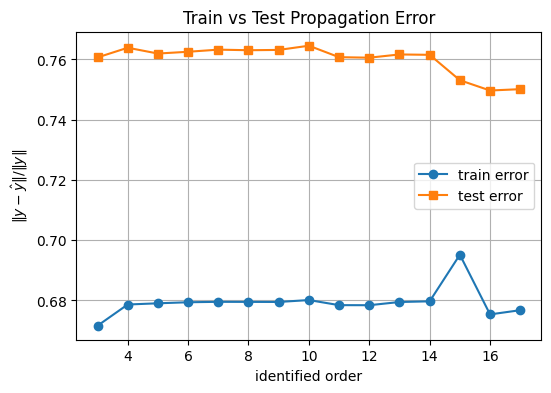

In [280]:
orders = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

results = {}
train_errs = []
test_errs = []
sing_vals = {}
eig_vals = {}

for n in orders:
    A_dt, B_dt, C_dt, D_dt, S_dt, X_dt = subspace_id_cva(u_train, y_train, s=40, n=n)
    results[n] = (A_dt, B_dt, C_dt, D_dt)

    sing_vals[n] = S_dt
    eig_vals[n] = np.linalg.eigvals(A_dt)

    yhat_train, _ = simulate_dts(A_dt, B_dt, C_dt, D_dt, u_train)
    train_err = np.linalg.norm(y_train - yhat_train) / np.linalg.norm(y_train)
    train_errs.append(train_err)

    yhat_test, _ = simulate_dts(A_dt, B_dt, C_dt, D_dt, u_test)
    test_err = np.linalg.norm(y_test - yhat_test) / np.linalg.norm(y_test)
    test_errs.append(test_err)

plt.figure(figsize=(6,4))

plt.plot(orders, train_errs, marker='o', label='train error')
plt.plot(orders, test_errs, marker='s', label='test error')

plt.xlabel("identified order")
plt.ylabel(r"$\|y - \hat{y}\| / \|y\|$")
plt.title("Train vs Test Propagation Error")
plt.grid(True)
plt.legend()
plt.savefig("figures/train_test_errs_orders.png")
plt.show()

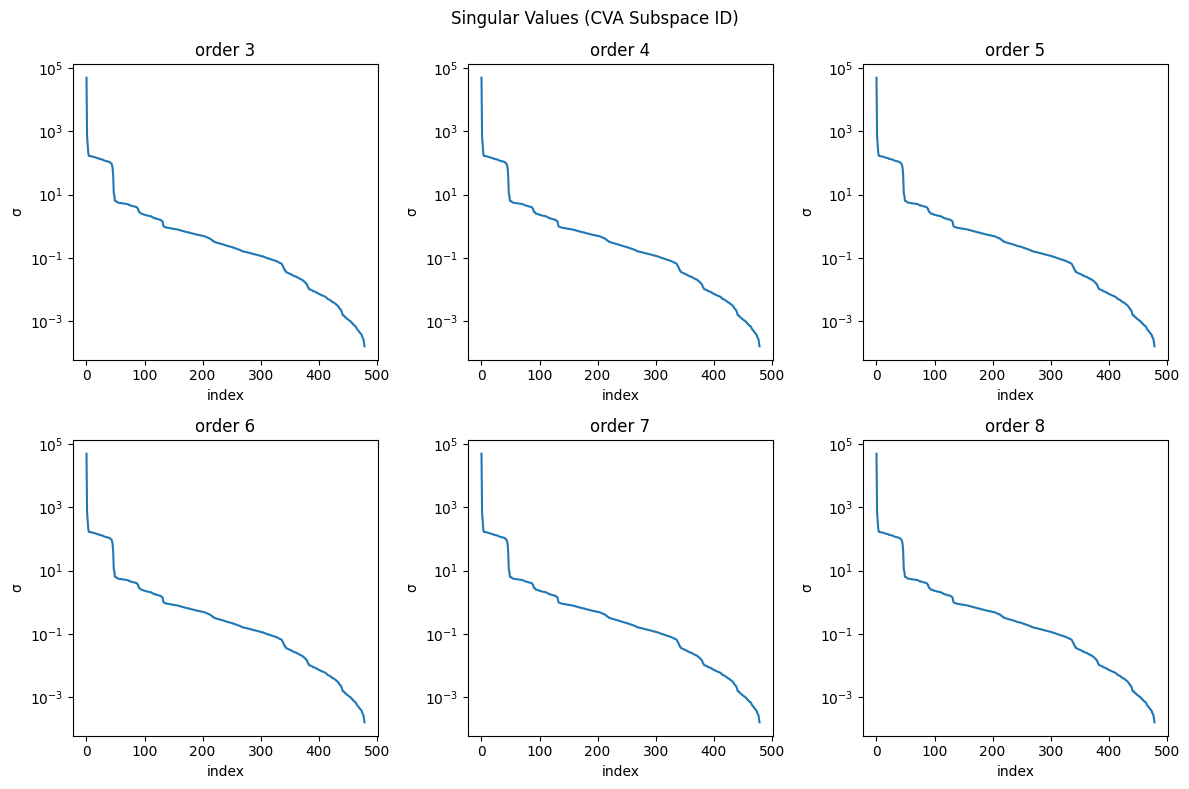

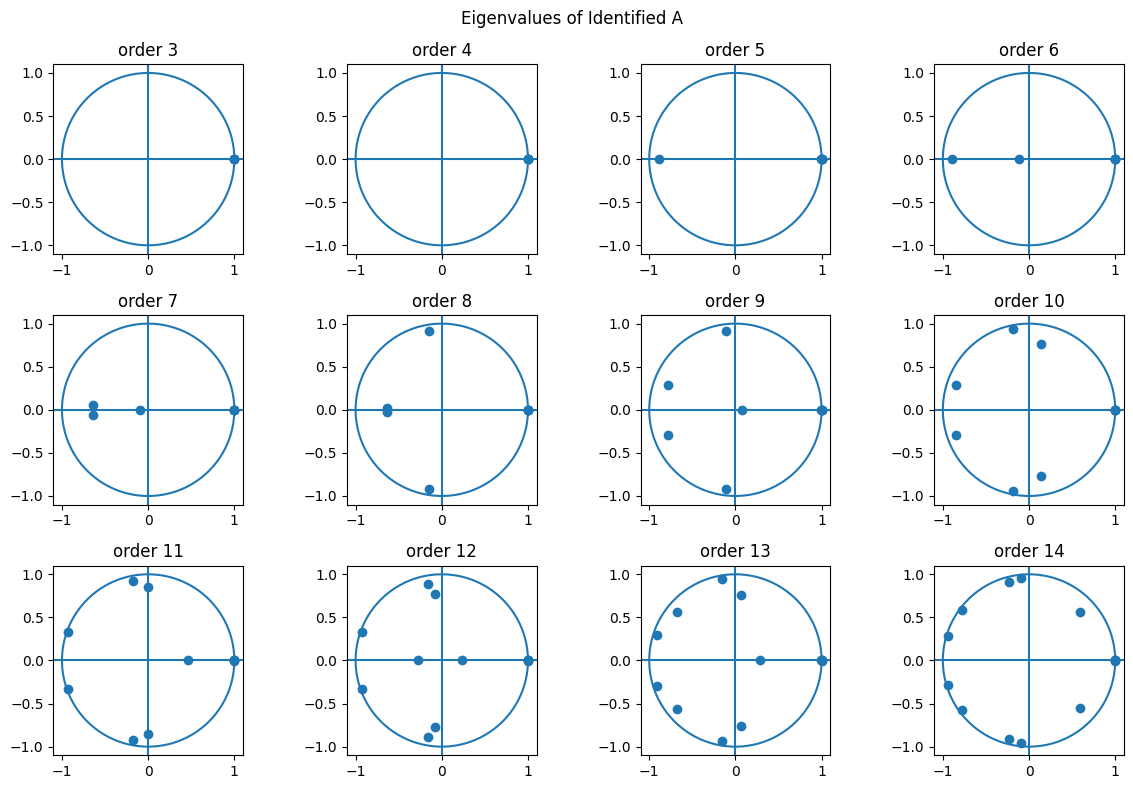

In [281]:
# -------------------------
# Singular value megaplot
# -------------------------

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, n in zip(axes.flatten(), orders):
    ax.semilogy(sing_vals[n])
    ax.set_title(f"order {n}")
    ax.set_xlabel("index")
    ax.set_ylabel("σ")

plt.suptitle("Singular Values (CVA Subspace ID)")
plt.tight_layout()
plt.savefig("figures/singular_values_orders_subspace_id.png")
plt.show()


# -------------------------
# Eigenvalue megaplot
# -------------------------

fig, axes = plt.subplots(3, 4, figsize=(12,8))

theta = np.linspace(0, 2*np.pi, 200)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

for ax, n in zip(axes.flatten(), orders):
    eig = eig_vals[n]

    ax.scatter(eig.real, eig.imag)
    ax.plot(circle_x, circle_y)   # unit circle
    ax.axhline(0)
    ax.axvline(0)

    ax.set_title(f"order {n}")
    ax.set_aspect('equal')

plt.suptitle("Eigenvalues of Identified A")
plt.tight_layout()
plt.savefig("figures/eigenvalues_dt_orders.png")
plt.show()

All of these are inside the unit circle which is comforting.

## AIC and BIC Complexity Analysis ##


order 3: train_err=0.6716, test_err=0.7607, k=105, AIC=2012922.04, BIC=2013940.04
order 4: train_err=0.6786, test_err=0.7639, k=128, AIC=2013980.07, BIC=2015221.06
order 5: train_err=0.6790, test_err=0.7620, k=153, AIC=2013423.42, BIC=2014906.79
order 6: train_err=0.6794, test_err=0.7626, k=180, AIC=2013663.78, BIC=2015408.92
order 7: train_err=0.6795, test_err=0.7633, k=209, AIC=2013943.16, BIC=2015969.47
order 8: train_err=0.6795, test_err=0.7631, k=240, AIC=2013944.46, BIC=2016271.32
order 9: train_err=0.6795, test_err=0.7632, k=273, AIC=2014041.73, BIC=2016688.54
order 10: train_err=0.6801, test_err=0.7646, k=308, AIC=2014550.24, BIC=2017536.38
order 11: train_err=0.6784, test_err=0.7608, k=345, AIC=2013426.86, BIC=2016771.72
order 12: train_err=0.6784, test_err=0.7606, k=384, AIC=2013451.54, BIC=2017174.52
order 13: train_err=0.6795, test_err=0.7617, k=425, AIC=2013872.94, BIC=2017993.42
order 14: train_err=0.6797, test_err=0.7615, k=468, AIC=2013919.90, BIC=2018457.28
order 15: t

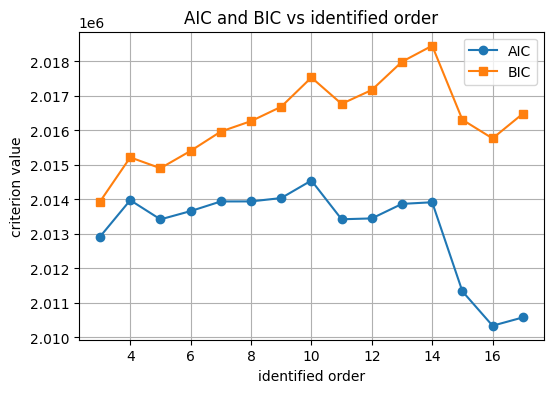

In [282]:
def aic_bic_from_residuals(y, yhat, n_states, m_inputs, p_outputs, include_D=True):
    N = y.shape[1]
    resid = y - yhat
    sse = np.sum(resid**2)
    sigma2 = sse / (N * p_outputs)

    if include_D:
        k_params = n_states**2 + n_states*m_inputs + p_outputs*n_states + p_outputs*m_inputs
    else:
        k_params = n_states**2 + n_states*m_inputs + p_outputs*n_states

    aic = N*p_outputs * np.log(sigma2) + 2 * k_params
    bic = N*p_outputs*np.log(sigma2) + k_params * np.log(N * p_outputs)

    return sse, sigma2, k_params, aic, bic

results_comp = {}
train_errs_comp = []
test_errs_comp = []
aics = []
bics = []
k_list = []
sigma2_list = []
sing_vals_comp = {}
eig_vals_comp = {}

for n in orders:
    A_dt, B_dt, C_dt, D_dt, S_dt, X_dt = subspace_id_cva(u_train, y_train, s=40, n=n)
    results[n] = (A_dt, B_dt, C_dt, D_dt)

    sing_vals[n] = S_dt
    eig_vals[n] = np.linalg.eigvals(A_dt)

    # training error
    yhat_train, _ = simulate_dts(A_dt, B_dt, C_dt, D_dt, u_train)
    train_err = np.linalg.norm(y_train - yhat_train) / np.linalg.norm(y_train)
    train_errs.append(train_err)

    # test error
    yhat_test, _ = simulate_dts(A_dt, B_dt, C_dt, D_dt, u_test)
    test_err = np.linalg.norm(y_test - yhat_test) / np.linalg.norm(y_test)
    test_errs.append(test_err)

    # AIC / BIC from test residuals
    sse, sigma2, k_params, aic, bic = aic_bic_from_residuals(
        y_test, yhat_test,
        n_states=n,
        m_inputs=u_test.shape[0],
        p_outputs=y_test.shape[0],
        include_D=True
    )

    sigma2_list.append(sigma2)
    k_list.append(k_params)
    aics.append(aic)
    bics.append(bic)

    print(
        f"order {n}: "
        f"train_err={train_err:.4f}, "
        f"test_err={test_err:.4f}, "
        f"k={k_params}, "
        f"AIC={aic:.2f}, "
        f"BIC={bic:.2f}"
    )

plt.figure(figsize=(6,4))
plt.plot(orders, aics, marker='o', label='AIC')
plt.plot(orders, bics, marker='s', label='BIC')
plt.xlabel("identified order")
plt.ylabel("criterion value")
plt.title("AIC and BIC vs identified order")
plt.grid(True)
plt.legend()
plt.savefig("figures/aicbic.png")
plt.show()
    

## Interpretation: Four Strong Modes in a 16th Order Model ##

We can clearly see the same story throughout: the model has three or four really dominant modes, but it has twelve other noticeable modes and really thinks it's sixteenth order, because the errors are smallest there and the largest singular value drop happens around 16. This is perfectly consistent with the model we created which is sixteenth order.

In [283]:
A_learned = results[16][0]
B_learned = results[16][1]
C_learned = results[16][2]
D_learned = results[16][3]
np.savez(
    "data/ABCD_learned.npz",
    A=A_learned,
    B=B_learned,
    C=C_learned,
    D=D_learned
)
